## Theory

Predictive maintenance is a machine-learning approach used to identify potential equipment failures before they occur. In industrial environments, unexpected machine failures can cause production downtime, increased maintenance costs, and equipment damage. Instead of waiting for a machine to fail, predictive maintenance analyzes historical operating conditions and learns patterns associated with failures. In this project, machine operating parameters are used to predict whether a machine is likely to experience a failure.

## Problem Statement

Industrial machines generate various operating measurements such as temperature, rotational speed, torque, and tool wear. Manually monitoring these parameters and identifying failure patterns can be difficult and inefficient. The objective of this project is to develop a binary classification system that uses machine operating conditions to predict whether a machine will fail or continue operating normally.

## Proposed Solution

The proposed SentinelOps AI system uses machine learning models to analyze the operating conditions of industrial equipment and predict failure risk. Random Forest and XGBoost will be trained as baseline classification models and evaluated using suitable classification metrics. An Artificial Neural Network will later be trained on the same features and compared with the classical machine-learning models. The best-performing model will be used as the initial failure-prediction component of the SentinelOps AI maintenance system.



# lets import needed libraries first


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset

The AI4I 2020 Predictive Maintenance Dataset is used for the initial failure-prediction module. It contains approximately 10,000 records representing operating conditions of industrial machines. The dataset includes features such as machine type, air temperature, process temperature, rotational speed, torque, and tool wear. The target variable is `Machine failure`, where `0` represents no machine failure and `1` represents machine failure. The dataset also contains individual failure-mode indicators, which will be handled carefully during feature selection to prevent data leakage.

In [2]:
df=pd.read_csv("/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv")

In [3]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [4]:
df.tail()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### Quartile and Maximum Analysis

For the **Rotational Speed [rpm]** feature:

- **Q1 = 1423 RPM:** 25% of observations have values less than or equal to 1423 RPM.
- **Median = 1503 RPM:** 50% of observations have values less than or equal to 1503 RPM.
- **Q3 = 1612 RPM:** 75% of observations have values less than or equal to 1612 RPM.
- **Maximum = 2886 RPM:** 2886 RPM is the highest observed value.

The substantial difference between Q3 (1612 RPM) and the maximum (2886 RPM) indicates that some observations in the upper range may be unusually high. However, a high maximum value alone is not sufficient to classify observations as outliers. The **Interquartile Range (IQR)** and boxplot analysis will be used to formally assess potential outliers.

In predictive maintenance, extreme values should not be removed automatically because they may represent genuine abnormal operating conditions that are useful for failure prediction.


In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

This data is clean and contains no missing values,so its easier to proceed
-


In [7]:
df.duplicated().sum()

np.int64(0)

No duplicate values are present
-

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

most data is numerical so its better for prediction
-

In [9]:
df.nunique()

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

UDI and product ID have all of their values unique and it was expected, they are identfier columns and wont help in prediction
-

In [10]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

# Univariate Analysis

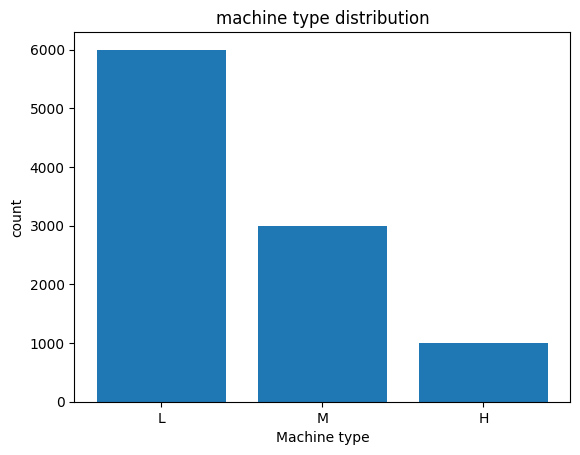

In [11]:
counts=df["Type"].value_counts()

plt.bar(counts.index, counts.values)
plt.title("machine type distribution")
plt.xlabel("Machine type")
plt.ylabel("count")
plt.show()

Here,L and H machine types contains most of the machines while H types are in minority, but that tells us about its  count only, we need to see if the machine type affects machine failure or not
--

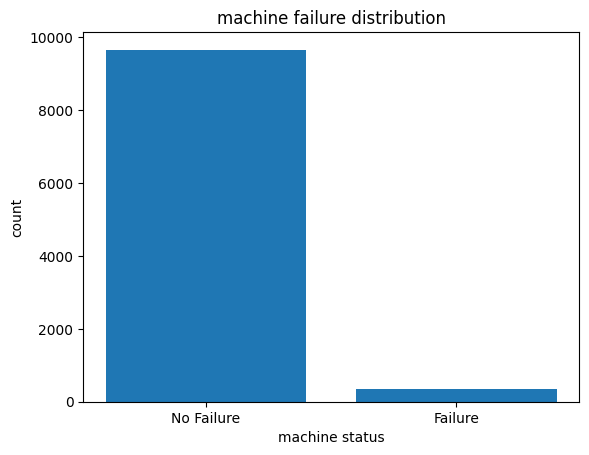

In [12]:
counts = df["Machine failure"].value_counts()

plt.bar(["No Failure", "Failure"],counts.values)

plt.title("machine failure distribution")
plt.xlabel("machine status")
plt.ylabel("count")
plt.show()

Majority of the machines operate without any failure, so data contains only tiny amount of reporting failure, so recall should be our prior metric to evalaute rather than accuracy since failure is rare in this data
--

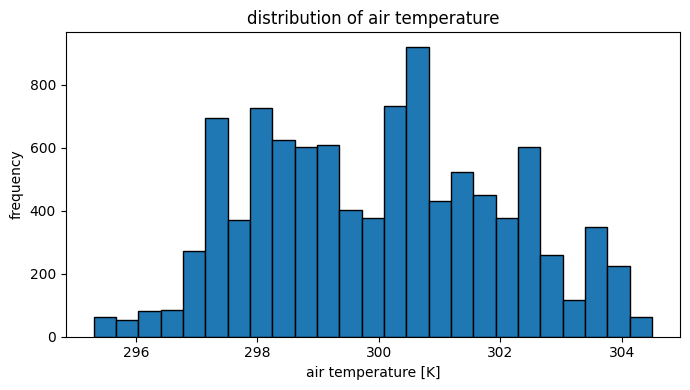

In [18]:
plt.figure(figsize=(7,4))

plt.hist(df["Air temperature [K]"], bins=25, edgecolor="black")

plt.title("distribution of air temperature")
plt.xlabel("air temperature [K]")
plt.ylabel("frequency")

plt.tight_layout()
plt.show()

Air temprature is ranging between 296k to 304.5k, there are no extreme spikes in temprature
--

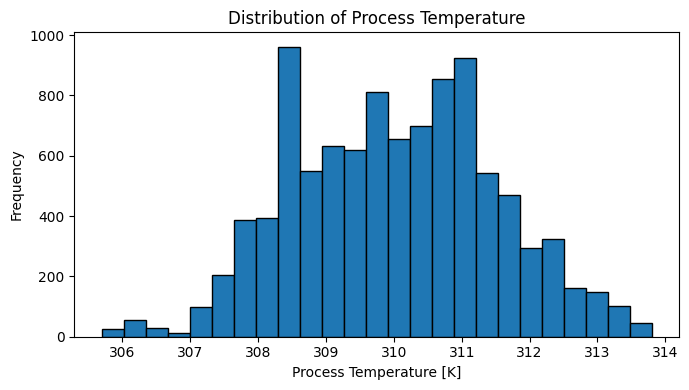

In [14]:
plt.figure(figsize=(7,4))
plt.hist(df["Process temperature [K]"], bins=25, edgecolor="black")
plt.title("Distribution of Process Temperature")
plt.xlabel("Process Temperature [K]")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


Similarly, here most observations are between 308k and 312k, less values at the extreme end, but theres no instant spike in process temprature either
--

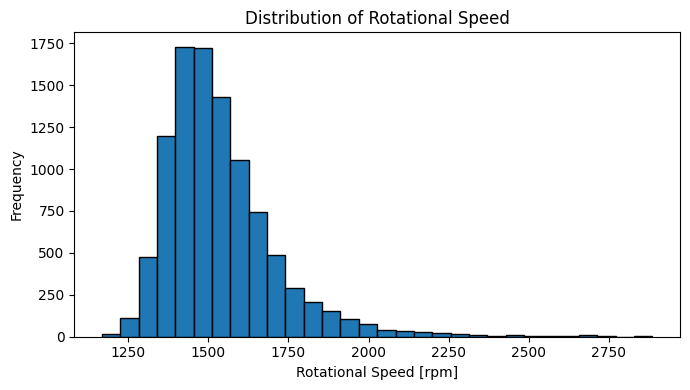

In [15]:
plt.figure(figsize=(7,4))
plt.hist(df["Rotational speed [rpm]"], bins=30, edgecolor="black")
plt.title("distribution of rotational Speed")
plt.xlabel("rotational speed [rpm]")
plt.ylabel("frequency")

plt.tight_layout()
plt.show()

As we saw from Data description,75% are withing  roughly 1240 RPM to 2000 RPM. but the RPM has less,but values at exteme point upto ~2800 RPM, so its rightly skewed but for outliers we still need to check boxplot.
--

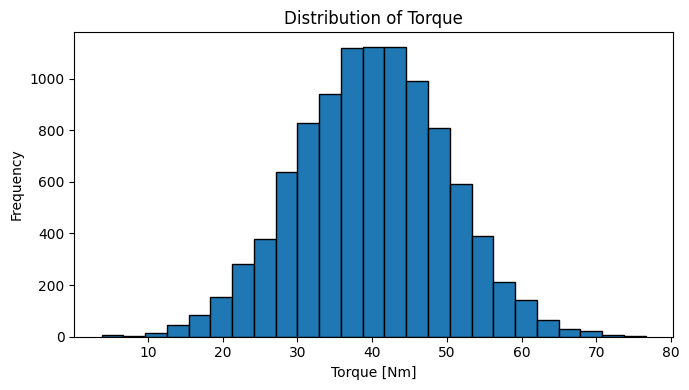

In [16]:
plt.figure(figsize=(7,4))
plt.hist(df["Torque [Nm]"], bins=25, edgecolor="black")
plt.title("distribution of torque")
plt.xlabel("torque [Nm]")
plt.ylabel("frequency")

plt.tight_layout()
plt.show()

Torque has normal distribution, with most values at 40 Nm, ranging from roughly 4Nm to 76 Nm.
--

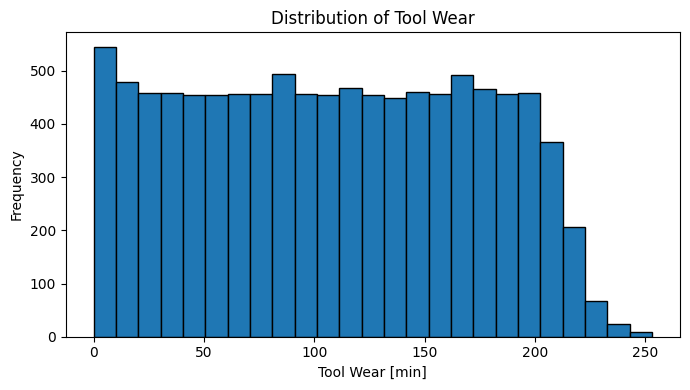

In [17]:
plt.figure(figsize=(7,4))
plt.hist(df["Tool wear [min]"], bins=25, edgecolor="black")
plt.title("distribution of tool wear")
plt.xlabel("tool wear [min]")
plt.ylabel("frequency")

plt.tight_layout()
plt.show()

Range for tool wear is 0 to 255 minutes, with majorly below 200 minutes, then theres a sharpe decline in number of observations after 200 minutes to 255 minutes, so its slightly rightly skewed.
--

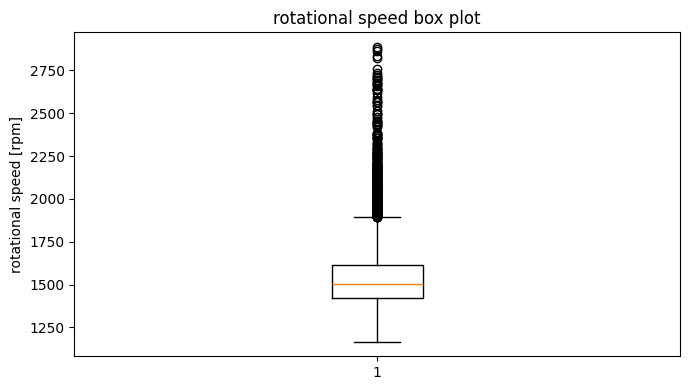

In [19]:
plt.figure(figsize=(7,4))
plt.boxplot(df["Rotational speed [rpm]"])
plt.title("rotational speed box plot")
plt.ylabel("rotational speed [rpm]")
plt.tight_layout()
plt.show()

In [20]:
q1=df["Rotational speed [rpm]"].quantile(0.25)
q3=df["Rotational speed [rpm]"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
print("q1:",q1)
print("q3:",q3)
print("iqr:",iqr)
print("lower bound:",lower)
print("upper bound:",upper)

q1: 1423.0
q3: 1612.0
iqr: 189.0
lower bound: 1139.5
upper bound: 1895.5


rotational speed — box plot
--
- Median is approximately **1500 rpm**.
- Q1 = **1423 rpm**.
- Q3 = **1612 rpm**.
- IQR = **189 rpm**.
- Lower bound = **1139.5 rpm**.
- Upper bound = **1895.5 rpm**.
- Several observations are above the upper bound, indicating **potential outliers**.
- No lower outliers are detected using the IQR rule.
- High rotational-speed values are retained because they may represent legitimate machine operating conditions.


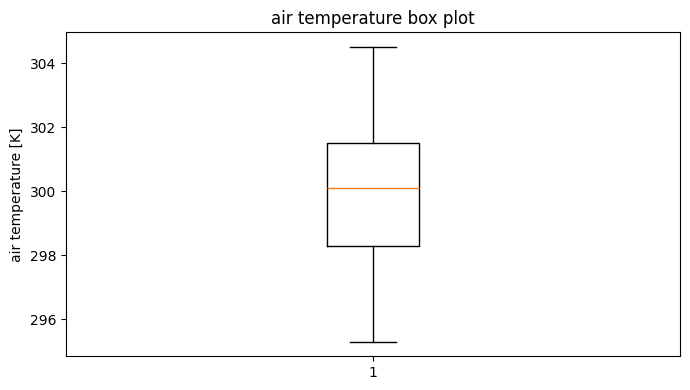

In [21]:
plt.figure(figsize=(7,4))
plt.boxplot(df["Air temperature [K]"])
plt.title("air temperature box plot")
plt.ylabel("air temperature [K]")
plt.tight_layout()
plt.show()

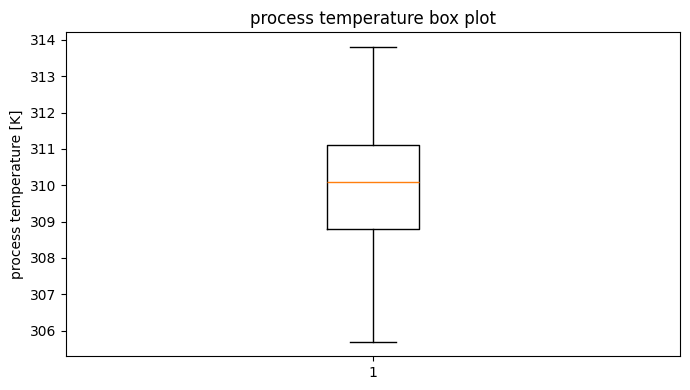

In [22]:
plt.figure(figsize=(7,4))
plt.boxplot(df["Process temperature [K]"])
plt.title("process temperature box plot")
plt.ylabel("process temperature [K]")
plt.tight_layout()
plt.show()

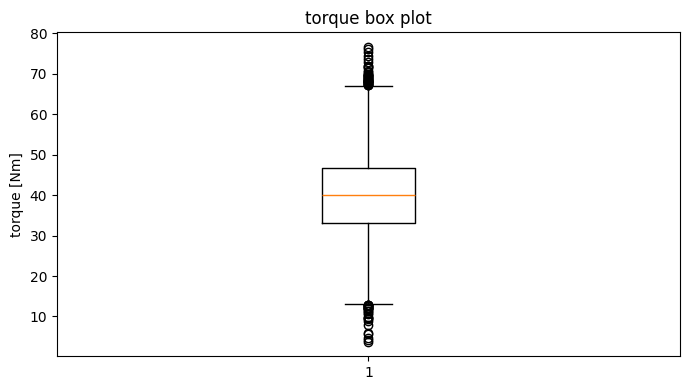

In [23]:
plt.figure(figsize=(7,4))
plt.boxplot(df["Torque [Nm]"])
plt.title("torque box plot")
plt.ylabel("torque [Nm]")
plt.tight_layout()
plt.show()

In [25]:
q1=df["Torque [Nm]"].quantile(0.25)
q3=df["Torque [Nm]"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
print("q1:",q1)
print("q3:",q3)
print("iqr:",iqr)
print("lower bound:",lower)
print("upper bound:",upper)

q1: 33.2
q3: 46.8
iqr: 13.599999999999994
lower bound: 12.800000000000011
upper bound: 67.19999999999999


 torque — iqr outlier analysis
 --
- Q1 = **33.2 Nm**.
- Q3 = **46.8 Nm**.
- IQR = **13.6 Nm**.
- Lower bound = **12.8 Nm**.
- Upper bound = **67.2 Nm**.
- Values below 12.8 Nm are considered potential lower outliers.
- Values above 67.2 Nm are considered potential upper outliers.
- Potential outliers are present on both sides of the distribution.
- These observations are retained because they may represent legitimate machine operating conditions.

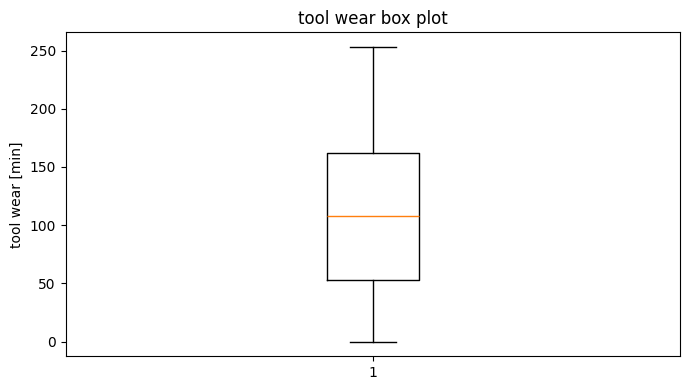

In [24]:
plt.figure(figsize=(7,4))
plt.boxplot(df["Tool wear [min]"])
plt.title("tool wear box plot")
plt.ylabel("tool wear [min]")
plt.tight_layout()
plt.show()

# Bivariate Analysis

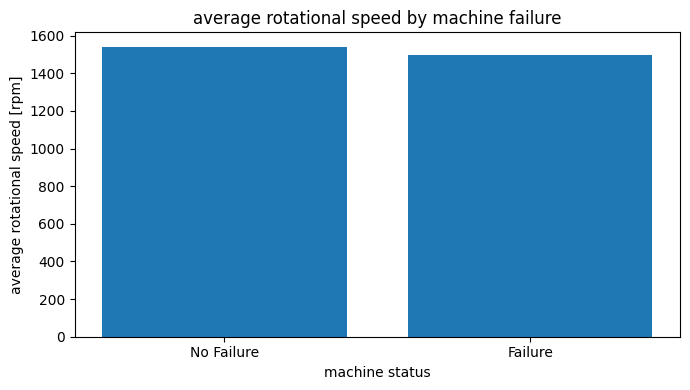

In [26]:
failure_speed=df.groupby("Machine failure")["Rotational speed [rpm]"].mean()
plt.figure(figsize=(7,4))
plt.bar(["No Failure","Failure"],failure_speed.values)
plt.title("average rotational speed by machine failure")
plt.xlabel("machine status")
plt.ylabel("average rotational speed [rpm]")
plt.tight_layout()
plt.show()

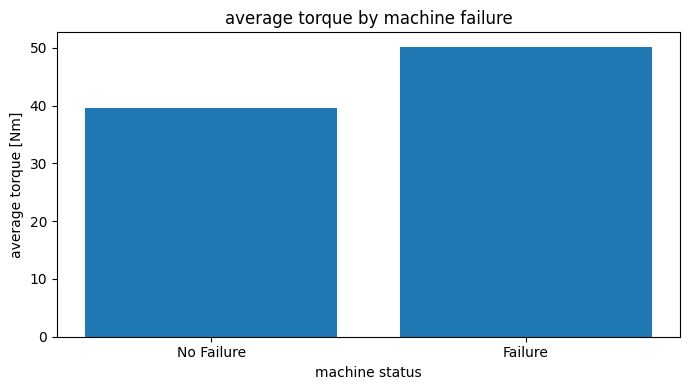

In [27]:
failure_torque=df.groupby("Machine failure")["Torque [Nm]"].mean()
plt.figure(figsize=(7,4))
plt.bar(["No Failure","Failure"],failure_torque.values)
plt.title("average torque by machine failure")
plt.xlabel("machine status")
plt.ylabel("average torque [Nm]")
plt.tight_layout()
plt.show()

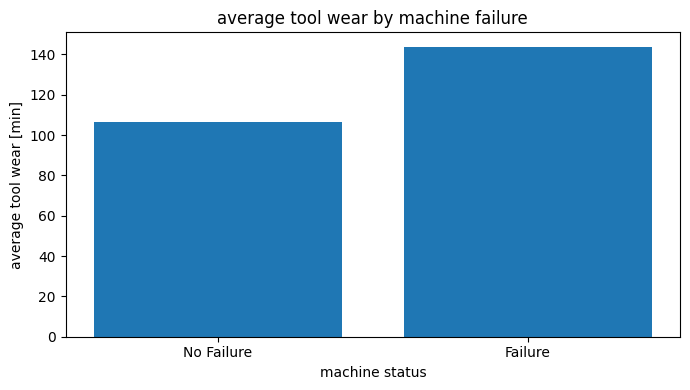

In [28]:
failure_wear=df.groupby("Machine failure")["Tool wear [min]"].mean()
plt.figure(figsize=(7,4))
plt.bar(["No Failure","Failure"],failure_wear.values)
plt.title("average tool wear by machine failure")
plt.xlabel("machine status")
plt.ylabel("average tool wear [min]")
plt.tight_layout()
plt.show()

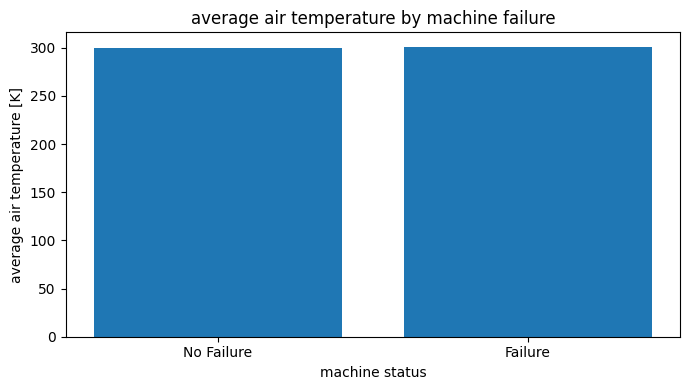

In [29]:
failure_air=df.groupby("Machine failure")["Air temperature [K]"].mean()
plt.figure(figsize=(7,4))
plt.bar(["No Failure","Failure"],failure_air.values)
plt.title("average air temperature by machine failure")
plt.xlabel("machine status")
plt.ylabel("average air temperature [K]")
plt.tight_layout()
plt.show()

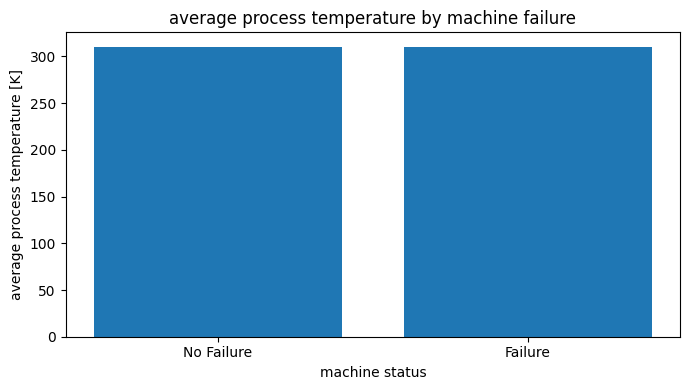

In [30]:
failure_process=df.groupby("Machine failure")["Process temperature [K]"].mean()
plt.figure(figsize=(7,4))
plt.bar(["No Failure","Failure"],failure_process.values)
plt.title("average process temperature by machine failure")
plt.xlabel("machine status")
plt.ylabel("average process temperature [K]")
plt.tight_layout()
plt.show()

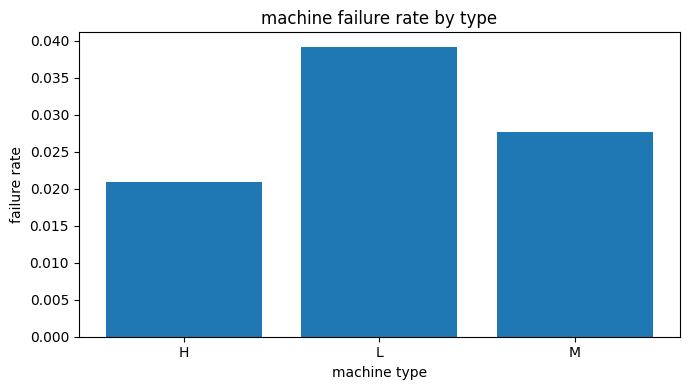

In [31]:
failure_type=df.groupby("Type")["Machine failure"].mean()
plt.figure(figsize=(7,4))
plt.bar(failure_type.index,failure_type.values)
plt.title("machine failure rate by type")
plt.xlabel("machine type")
plt.ylabel("failure rate")
plt.tight_layout()
plt.show()


**torque vs machine failure**
--
- Failure cases show a noticeably higher average torque than no-failure cases.
- Average torque is approximately **50 Nm** for failure cases compared with **40 Nm** for no-failure cases.
- Higher torque may therefore be associated with an increased likelihood of machine failure.

**tool wear vs machine failure**
--
- Failure cases show noticeably higher average tool wear than no-failure cases.
- Average tool wear is approximately **143 minutes** for failure cases compared with **107 minutes** for no-failure cases.
- Higher tool wear may therefore be associated with machine failure.

**machine type vs machine failure**
--
- Failure rates differ across the three machine types.
- **L-type** machines have the highest failure rate at approximately **3.9%**.
- **M-type** machines have a failure rate of approximately **2.8%**.
- **H-type** machines have the lowest failure rate at approximately **2.1%**.
- Machine type may therefore have a relationship with failure occurrence.

**air temperature and process temperature vs machine failure**
--
- Both temperature variables show very similar average values between failure and no-failure cases.
- No significant difference is visible from the average comparison.
- These variables do not show a strong direct relationship with machine failure based on this analysis alone.
- Similar averages do not necessarily mean that these features are irrelevant.

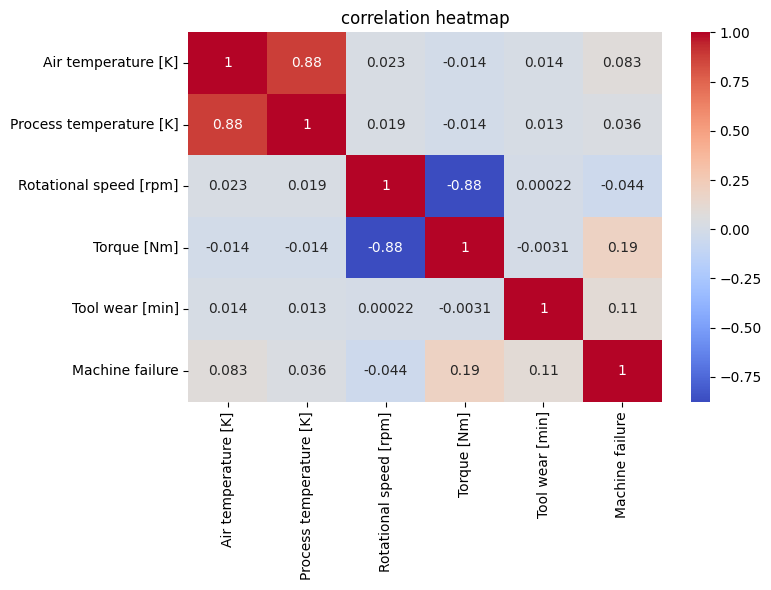

In [34]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df[["Air temperature [K]","Process temperature [K]","Rotational speed [rpm]","Torque [Nm]","Tool wear [min]","Machine failure"]].corr(),annot=True,cmap="coolwarm")
plt.title("correlation heatmap")
plt.tight_layout()
plt.show()

**correlation heatmap**
--
- Air temperature and process temperature show a strong positive correlation of **0.88**.
- Rotational speed and torque show a strong negative correlation of **-0.88**.
- Torque has the strongest correlation with machine failure at **0.19**, indicating a weak positive relationship.
- Tool wear has a weak positive correlation with machine failure at **0.11**.
- Air temperature, process temperature, and rotational speed show very weak correlations with machine failure.
- The strong correlation between air temperature and process temperature indicates that these two features contain similar information.
- Overall, the heatmap suggests that **torque and tool wear have stronger linear relationships with machine failure** than the other numerical features.

# Multivariate Analysis

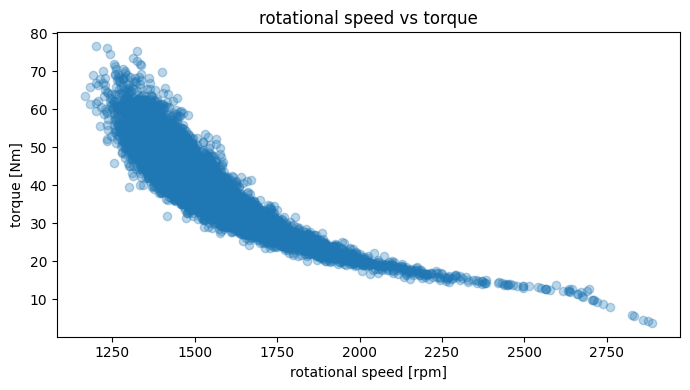

In [35]:
plt.figure(figsize=(7,4))
plt.scatter(df["Rotational speed [rpm]"],df["Torque [Nm]"],alpha=0.3)
plt.title("rotational speed vs torque")
plt.xlabel("rotational speed [rpm]")
plt.ylabel("torque [Nm]")
plt.tight_layout()
plt.show()

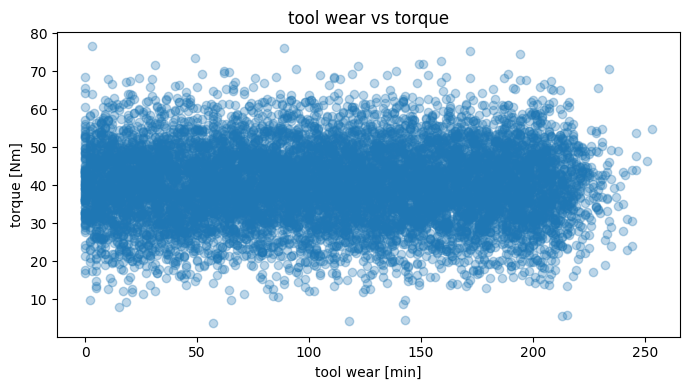

In [36]:
plt.figure(figsize=(7,4))
plt.scatter(df["Tool wear [min]"],df["Torque [Nm]"],alpha=0.3)
plt.title("tool wear vs torque")
plt.xlabel("tool wear [min]")
plt.ylabel("torque [Nm]")
plt.tight_layout()
plt.show()

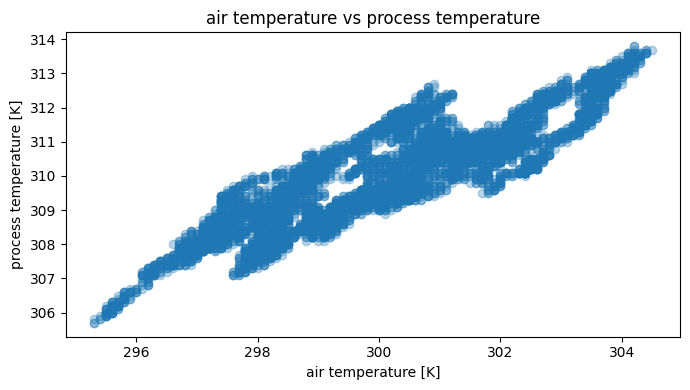

In [37]:
plt.figure(figsize=(7,4))
plt.scatter(df["Air temperature [K]"],df["Process temperature [K]"],alpha=0.3)
plt.title("air temperature vs process temperature")
plt.xlabel("air temperature [K]")
plt.ylabel("process temperature [K]")
plt.tight_layout()
plt.show()



**rotational speed vs torque**
--
- Strong negative relationship between rotational speed and torque.
- As rotational speed increases, torque generally decreases.
- Confirms the **-0.88 correlation** from the heatmap.

**tool wear vs torque**
--
- Points are widely scattered with no clear trend.
- Indicates a weak relationship between tool wear and torque.

**air temperature vs process temperature**
--
- Clear positive relationship between the two variables.
- Confirms the **0.88 correlation** from the heatmap.

#  Our EDA is compelete now lets move to feature engineering